# RL Group Project: Configuration B
## Clinical Treatment Optimisation: Sepsis ICU Management — Continuous Observations

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This notebook covers **Configuration B**, where the agent operates in the full continuous-observation ICU-Sepsis environment with three clinical reality wrappers injecting realistic failure modes.

---
### Group Members

Name of the Group: Group AB

```
Student 1: Andreea Roica
Student 2: Marisa Esteves
Student 3: Miguel Caramelo
Student 4: Oliver Kain
```

## 0. Setup & Imports

In [2]:
# Install dependencies (run once if needed)
# !pip install icu-sepsis numpy pandas matplotlib seaborn torch gymnasium optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import random
import torch
import optuna

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

import importlib
import rl_configB_functions
importlib.reload(rl_configB_functions)

from rl_configB_functions import (
    # constants
    SEED, N_OBS, N_ACTIONS, GAMMA,
    # evaluation
    EvalMetricsB, evaluate_policy_b,
    # networks
    QNetwork, ActorCritic, ReplayBuffer,
    # agents
    DQNAgent, PPOAgent,
    # training
    train_dqn, train_ppo,
    # tuning
    run_optuna,
    # plotting
    moving_average, plot_return_curves, plot_survival_curves,
    dqn_convergence_episode,
)

from envs.wrappers import make_clinical_env

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots',       exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)
PLOTS_DIR = 'plots'

np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

print(f'Config B | Obs dim: {N_OBS} | Actions: {N_ACTIONS} | γ = {GAMMA}')
print(f'PyTorch  : {torch.__version__}')
print(f'Optuna   : {optuna.__version__}')
print('Setup complete!')

Config B | Obs dim: 47 | Actions: 25 | γ = 1.0
PyTorch  : 2.12.0+cpu
Optuna   : 4.8.0
Setup complete!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


---
## 1. Explore the Clinical Environment

Before designing any algorithm we inspect the environment structure, understand the
47-dimensional observation space, and establish a random-policy baseline.

In [3]:
env = make_clinical_env()
obs, info = env.reset(seed=SEED)

print('Clinical ICU-Sepsis environment')
print(f'  Observation space : {env.observation_space}')
print(f'  Action space      : {env.action_space}')
print(f'  Obs shape         : {obs.shape}  dtype={obs.dtype}')
print(f'  Info keys         : {list(info.keys())}')
print()
print('Wrapper stack (outermost first):')
e = env
while hasattr(e, 'env'):
    print(f'  {type(e).__name__}')
    e = e.env
print(f'  {type(e).__name__}  (base environment) base environment')
env.close()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Clinical ICU-Sepsis environment
  Observation space : Box(-inf, inf, (47,), float32)
  Action space      : Discrete(25)
  Obs shape         : (47,)  dtype=float32
  Info keys         : ['admissible_actions', 'state_vector', 'sofa_score', 'noisy_episode', 'missing_features']

Wrapper stack (outermost first):
  AcuteEventEnv
  EpisodicMissingObsEnv
  EpisodicNoisyObsEnv
  ContinuousICUSepsisEnv  (base environment) base environment


In [4]:
from envs.continuous_sepsis_env import FEATURE_NAMES

feat_df = pd.DataFrame({'index': range(len(FEATURE_NAMES)), 'feature': FEATURE_NAMES})
print(f'Physiological feature vector ({len(FEATURE_NAMES)} dimensions):')
print(feat_df.to_string(index=False))

Physiological feature vector (47 dimensions):
 index        feature
     0        Albumin
     1            ALP
     2            ALT
     3            AST
     4      Bilirubin
     5            BUN
     6       Chloride
     7     Creatinine
     8   Diastolic_BP
     9     Fibrinogen
    10           FiO2
    11            GCS
    12        Glucose
    13           HCO3
    14     Hemoglobin
    15            INR
    16        Lactate
    17          MgSO4
    18        Mean_BP
    19      Potassium
    20            PTT
    21          PaCO2
    22           PaO2
    23      Platelets
    24            RBC
    25           SOFA
    26         Sodium
    27    Systolic_BP
    28    Temperature
    29       Troponin
    30   Urine_Output
    31            WBC
    32         Weight
    33             Ca
    34        Heparin
    35             HR
    36      Na_Bicarb
    37        Insulin
    38 Norepinephrine
    39       Propofol
    40    Vasopressin
    41       Dopamine
    42  

### Random baseline

We evaluate a purely random policy on 50 000 episodes to establish a lower bound.
All trained agents must beat this baseline on survival rate and mean return.

In [5]:
np.random.seed(SEED)

clinical_rand_returns = []
noisy_returns, clean_returns    = [], []
missing_returns, nomiss_returns = [], []
acute_returns, noacute_returns = [], []

env_eval = make_clinical_env()
for ep in range(50000):
    obs, info = env_eval.reset(seed=int(np.random.randint(100_000)))
    total_r, done = 0.0, False
    ep_noisy   = info.get('noisy_episode', False)
    ep_missing = info.get('missing_features') is not None
    ep_acute   = False

    while not done:
        obs, r, te, tr, info = env_eval.step(env_eval.action_space.sample())
        total_r += r
        done     = te or tr
        if info.get('acute_event', False):
            ep_acute = True

    clinical_rand_returns.append(total_r)
    (noisy_returns   if ep_noisy   else clean_returns).append(total_r)
    (missing_returns if ep_missing else nomiss_returns).append(total_r)
    (acute_returns if ep_acute else noacute_returns).append(total_r)

env_eval.close()

clinical_rand_mean = float(np.mean(clinical_rand_returns))
clinical_rand_surv = float(np.mean(np.array(clinical_rand_returns) > 0))

print('=== Random Baseline (50 000 episodes) ===')
print(f'Overall mean return   : {clinical_rand_mean:.4f}')
print(f'Overall survival rate : {clinical_rand_surv:.1%}')
print()
print('Stratified by wrapper:')
print(f'  Noisy     ({len(noisy_returns):3d} eps) return={np.mean(noisy_returns):.4f}  surv={np.mean(np.array(noisy_returns)>0):.1%}')
print(f'  Clean     ({len(clean_returns):3d} eps) return={np.mean(clean_returns):.4f}  surv={np.mean(np.array(clean_returns)>0):.1%}')
print(f'  Missing   ({len(missing_returns):3d} eps) return={np.mean(missing_returns):.4f}  surv={np.mean(np.array(missing_returns)>0):.1%}')
print(f'  Complete  ({len(nomiss_returns):3d} eps) return={np.mean(nomiss_returns):.4f}  surv={np.mean(np.array(nomiss_returns)>0):.1%}')
print(f'  Acute     ({len(acute_returns):3d} eps) return={np.mean(acute_returns):.4f}  surv={np.mean(np.array(acute_returns)>0):.1%}')
print(f'  Not acute     ({len(noacute_returns):3d} eps) return={np.mean(noacute_returns):.4f}  surv={np.mean(np.array(noacute_returns)>0):.1%}')
print()
print('All trained agents must beat this baseline.')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Random Baseline (50 000 episodes) ===
Overall mean return   : 0.5606
Overall survival rate : 65.4%

Stratified by wrapper:
  Noisy     (7509 eps) return=0.5605  surv=65.3%
  Clean     (42491 eps) return=0.5606  surv=65.4%
  Missing   (7620 eps) return=0.5532  surv=64.8%
  Complete  (42380 eps) return=0.5619  surv=65.5%
  Acute     (4127 eps) return=-0.0874  surv=0.0%
  Not acute     (45873 eps) return=0.6189  surv=71.3%

All trained agents must beat this baseline.


---
## 2. Experimental Configuration

### Why Double DQN?

With a 47-dimensional continuous observation space a Q-table is infeasible.
DQN uses a neural network to approximate $Q(s,a)$ across the continuous state
space. Two key stabilisation mechanisms address the instabilities of training
neural networks with RL objectives:

1. **Experience Replay** — transitions are stored in a buffer and sampled
   uniformly at random, breaking the temporal correlation of consecutive
   samples. The **buffer size** controls how much old experience is retained.
2. **Target Network** — a periodically-synced copy provides stable bootstrap
   targets, avoiding the moving-target problem. The **target update frequency**
   controls the lag between the online and target networks.

**Double DQN** further decouples action *selection* (online network) from
action *evaluation* (target network), reducing Q-value overestimation.

### Why PPO?

PPO is an on-policy policy-gradient method. It has **no replay buffer and no
target network**. It collects fresh rollouts with the current policy, computes
GAE advantages, and performs several clipped-objective update epochs before
discarding the data. This makes it a strong comparison point: we can see
whether value-based off-policy methods are better suited to this environment
than on-policy policy-gradient methods.

In [ ]:
# --- training budgets ---
N_EPISODES = 50000

# --- Optuna tuning budgets (kept small relative to the final run) ---
N_TRIALS          = 20
N_EPISODES_TUNE   = 10000
EVAL_EPISODES_TUNE = 500

# --- evaluation budget ---
EVAL_EPISODES = 1000

# --- learning-curve smoothing window ---
MA_WINDOW = 500

print(f'Training episodes: {N_EPISODES:,}')
print(f'Optuna trials    : {N_TRIALS} x {N_EPISODES_TUNE} episodes')
print(f'Eval episodes    : {EVAL_EPISODES}')
print(f'MA window        : {MA_WINDOW}')

DEBUG_MODE       : False
Training episodes: 50,000
Optuna trials    : 20 × 10000 episodes
Eval episodes    : 1000
MA window        : 500


---
## 3. Hyperparameter Search with Optuna

We use Optuna  to search for good hyperparameters for each algorithm
on a small episode budget. The best parameters found are then used for the full
50 000-episode run.

For Double DQN the search space explicitly includes **buffer_size** and
**target_update_freq** — the two key knobs that control the stability of
value-based off-policy learning.

PPO has no replay buffer or target network; its search space covers rollout
length, clip epsilon, GAE lambda and the entropy coefficient.

### 3a. Optuna — Double DQN

In [ ]:
best_params_ddqn, study_ddqn = run_optuna(
    'ddqn',
    n_trials=N_TRIALS,
    n_episodes_tune=N_EPISODES_TUNE,
    eval_episodes=EVAL_EPISODES_TUNE,
    metric='combined',
    seed=SEED,
    verbose=True,
)

ddqn_pareto_df = pd.DataFrame([
    {
        'trial': t.number,
        'survival_rate': t.values[0],
        'mean_return': t.values[1],
        **t.params,
    }
    for t in study_ddqn.best_trials
]).sort_values(['survival_rate', 'mean_return'], ascending=False)

ddqn_pareto_df.set_index('trial', inplace=True)

display(ddqn_pareto_df)

print('Double DQN best params :', best_params_ddqn)
print(f"  -> buffer_size        = {best_params_ddqn['buffer_size']}")
print(f"  -> target_update_freq = {best_params_ddqn['target_update_freq']}")

  0%|          | 0/20 [00:00<?, ?it/s]

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsi

In [ ]:
# Optuna trial summary table — Double DQN
ddqn_trials_df = pd.DataFrame([
    {
        **t.params,
        'survival_rate': t.values[0],
        'mean_return': t.values[1],
        'trial': t.number,
    }
    for t in study_ddqn.trials
    if t.values is not None
]).sort_values(['survival_rate', 'mean_return'], ascending=False)

ddqn_trials_df.set_index('trial', inplace=True)

display(ddqn_trials_df.head(10).round(5))

print('\nbuffer_size vs. mean return (Double DQN):')
print(ddqn_trials_df.groupby('buffer_size')['mean_return'].mean().round(4))

print('\nbuffer_size vs. survival rate (Double DQN):')
print(ddqn_trials_df.groupby('buffer_size')['survival_rate'].mean().round(4))

print('\ntarget_update_freq vs. mean return (Double DQN):')
print(ddqn_trials_df.groupby('target_update_freq')['mean_return'].mean().round(4))

print('\ntarget_update_freq vs. survival rate (Double DQN):')
print(ddqn_trials_df.groupby('target_update_freq')['survival_rate'].mean().round(4))

,net_arch,lr,exploration_fraction,epsilon_min,batch_size,buffer_size,target_update_freq,gradient_steps,return,trial
0,128,0.00104,0.05,0.01,64,10000,100,1,0.61650,0
16,128,0.00135,0.20,0.01,32,50000,100,4,0.61239,16
18,128,0.00038,0.20,0.05,32,50000,50,4,0.61082,18
10,128,0.00298,0.10,0.01,32,10000,100,1,0.60866,10
6,128,0.00027,0.05,0.05,128,100000,50,2,0.60579,6
14,128,0.00177,0.10,0.01,32,10000,100,1,0.60362,14
1,256,0.00022,0.10,0.01,64,100000,250,1,0.60354,1
4,256,0.00069,0.05,0.10,128,100000,250,1,0.59928,4
11,128,0.00410,0.10,0.01,32,10000,100,1,0.59644,11
19,64,0.00136,0.20,0.10,64,50000,250,4,0.59280,19



buffer_size vs. mean return (Double DQN):
buffer_size
10000     0.5912
50000     0.5784
100000    0.5886
Name: return, dtype: float64

target_update_freq vs. mean return (Double DQN):
target_update_freq
50     0.5787
100    0.5904
250    0.5985
500    0.5754
Name: return, dtype: float64


### 3b. Optuna — PPO

In [ ]:
best_params_ppo, study_ppo = run_optuna(
    'ppo',
    n_trials=N_TRIALS,
    n_episodes_tune=N_EPISODES_TUNE,
    eval_episodes=EVAL_EPISODES_TUNE,
    metric='combined',
    seed=SEED,
    verbose=True,
)

ppo_pareto_df = pd.DataFrame([
    {
        'trial': t.number,
        'survival_rate': t.values[0],
        'mean_return': t.values[1],
        **t.params,
    }
    for t in study_ppo.best_trials
]).sort_values(['survival_rate', 'mean_return'], ascending=False)

ppo_pareto_df.set_index('trial', inplace=True)

display(ppo_pareto_df)

print('PPO best params :', best_params_ppo)
print(f"  -> rollout_length        = {best_params_ppo['rollout_length']}")
print(f"  -> clip_eps = {best_params_ppo['clip_eps']}")
print(f"  -> gae_lambda  = {best_params_ppo['gae_lambda']}")
print(f"  -> ent_coef = {best_params_ppo['ent_coef']}")

In [ ]:
# Optuna trial summary table — PPO

ppo_trials_df = pd.DataFrame([
    {
        **t.params,
        'survival_rate': t.values[0],
        'mean_return': t.values[1],
        'trial': t.number,
    }
    for t in study_ppo.trials
    if t.values is not None
]).sort_values(['survival_rate', 'mean_return'], ascending=False)

ppo_trials_df.set_index('trial', inplace=True)

display(ppo_trials_df.head(10).round(5))

print('\nclip_eps vs. mean return (PPO):')
print(ppo_trials_df.groupby('clip_eps')['mean_return'].mean().round(4))

print('\nclip_eps vs. survival rate (PPO):')
print(ppo_trials_df.groupby('clip_eps')['survival_rate'].mean().round(4))

print('\ngae_lambda vs. mean return (PPO):')
print(ppo_trials_df.groupby('gae_lambda')['mean_return'].mean().round(4))

print('\ngae_lambda vs. survival rate (PPO):')
print(ppo_trials_df.groupby('gae_lambda')['survival_rate'].mean().round(4))

print('\nentropy_coef vs. mean return (PPO):')
print(ppo_trials_df.groupby('entropy_coef')['mean_return'].mean().round(4))

print('\nentropy_coef vs. survival rate (PPO):')
print(ppo_trials_df.groupby('entropy_coef')['survival_rate'].mean().round(4))

print('\nrollout_length vs. mean return (PPO):')
print(ppo_trials_df.groupby('rollout_length')['mean_return'].mean().round(4))

print('\nrollout_length vs. survival rate (PPO):')
print(ppo_trials_df.groupby('rollout_length')['survival_rate'].mean().round(4))

### 3b. Optuna — Summary

In [ ]:
# Optuna tuning summary 

ddqn_selected = ddqn_pareto_df.iloc[0]
ppo_selected = ppo_pareto_df.iloc[0]

print('Optuna tuning summary')
print(
    f"  Double DQN selected: survival={ddqn_selected['survival_rate']:.4f} | "
    f"return={ddqn_selected['mean_return']:.4f} | "
    f"Pareto trials={len(ddqn_pareto_df)}"
)
print(
    f"  PPO        selected: survival={ppo_selected['survival_rate']:.4f} | "
    f"return={ppo_selected['mean_return']:.4f} | "
    f"Pareto trials={len(ppo_pareto_df)}"
)

NameError: name 'ddqn_pareto_df' is not defined

---
## 4. Final Training (up to 50 000 episodes)

Each agent is trained with its Optuna-selected hyperparameters for the full
episode budget. 
The `verbose=True` flag prints a progress line every 5 000 episodes.

### 4a. Final training — Double DQN

In [ ]:
hist_ddqn = train_dqn(
    n_episodes=N_EPISODES,
    double=True,
    seed=SEED,
    verbose=True,
    log_every=max(1, N_EPISODES // 10),
    **best_params_ddqn,
)

agent_ddqn = hist_ddqn['agent']
print(f"\nDouble DQN done  | buffer_size={best_params_ddqn['buffer_size']} "
      f"| target_update_freq={best_params_ddqn['target_update_freq']}")

torch.save(agent_ddqn.online_net.state_dict(), 'checkpoints/ddqn_configB.pt')
print('Checkpoint saved: checkpoints/ddqn_configB.pt')

make_sepsis_env | lam=0.02 -> intensity penalty active
make_sepsis_env | sofa_bias=5.0 -> mean start SOFA: 9.02
[Double DQN] Ep   5000/50000 | Return 0.573 | Survival 65.64% | ε=0.0100 | buffer= 10000
[Double DQN] Ep  10000/50000 | Return 0.579 | Survival 65.60% | ε=0.0100 | buffer= 10000
[Double DQN] Ep  15000/50000 | Return 0.576 | Survival 64.54% | ε=0.0100 | buffer= 10000
[Double DQN] Ep  20000/50000 | Return 0.594 | Survival 66.00% | ε=0.0100 | buffer= 10000
[Double DQN] Ep  25000/50000 | Return 0.617 | Survival 67.08% | ε=0.0100 | buffer= 10000
[Double DQN] Ep  30000/50000 | Return 0.621 | Survival 66.94% | ε=0.0100 | buffer= 10000
[Double DQN] Ep  35000/50000 | Return 0.625 | Survival 67.92% | ε=0.0100 | buffer= 10000
[Double DQN] Ep  40000/50000 | Return 0.610 | Survival 65.90% | ε=0.0100 | buffer= 10000
[Double DQN] Ep  45000/50000 | Return 0.623 | Survival 67.00% | ε=0.0100 | buffer= 10000
[Double DQN] Ep  50000/50000 | Return 0.609 | Survival 65.78% | ε=0.0100 | buffer= 1000

### 4b. Final training — PPO

In [ ]:
hist_ppo = train_ppo(
    n_episodes=N_EPISODES,
    seed=SEED,
    verbose=True,
    log_every=max(1, N_EPISODES // 10),
    **best_params_ppo,
)

agent_ppo = hist_ppo['agent']
upd = hist_ppo['ppo_updates']
if upd['policy_loss']:
    print(f"\nPPO done | last update: p_loss={upd['policy_loss'][-1]:.4f} "
          f"v_loss={upd['value_loss'][-1]:.4f} "
          f"entropy={upd['entropy'][-1]:.3f} "
          f"clip={upd['clip_fraction'][-1]:.3f}")

torch.save(agent_ppo.net.state_dict(), 'checkpoints/ppo_configB.pt')
print('Checkpoint saved: checkpoints/ppo_configB.pt')

make_sepsis_env | lam=0.02 -> intensity penalty active
make_sepsis_env | sofa_bias=5.0 -> mean start SOFA: 9.02
[PPO] Ep   5000/50000 | Return 0.583 | Survival 65.88% | p_loss=-0.0228 entropy=2.430
[PPO] Ep  10000/50000 | Return 0.604 | Survival 66.44% | p_loss=-0.0242 entropy=2.382
[PPO] Ep  15000/50000 | Return 0.612 | Survival 66.54% | p_loss=-0.0227 entropy=2.242
[PPO] Ep  20000/50000 | Return 0.613 | Survival 67.06% | p_loss=-0.0173 entropy=1.946
[PPO] Ep  25000/50000 | Return 0.636 | Survival 67.68% | p_loss=-0.0184 entropy=1.455
[PPO] Ep  30000/50000 | Return 0.637 | Survival 67.44% | p_loss=-0.0149 entropy=1.479
[PPO] Ep  35000/50000 | Return 0.636 | Survival 66.98% | p_loss=-0.0166 entropy=1.361
[PPO] Ep  40000/50000 | Return 0.653 | Survival 68.00% | p_loss=-0.0153 entropy=1.113
[PPO] Ep  45000/50000 | Return 0.646 | Survival 67.00% | p_loss=-0.0131 entropy=0.896
[PPO] Ep  50000/50000 | Return 0.646 | Survival 66.88% | p_loss=-0.0161 entropy=1.058

PPO done | last update: p_l

---
## 5. Learning Curves

Two focused plots comparing Double DQN and PPO 
on the same figure over the full training run:

1. **Episode return** — did the agent learn to accumulate higher reward?
2. **Survival rate** — is the agent keeping patients alive more often?

All curves use a causal moving average of window `MA_WINDOW` (preserves
episode alignment) and include the random-policy baseline for reference.

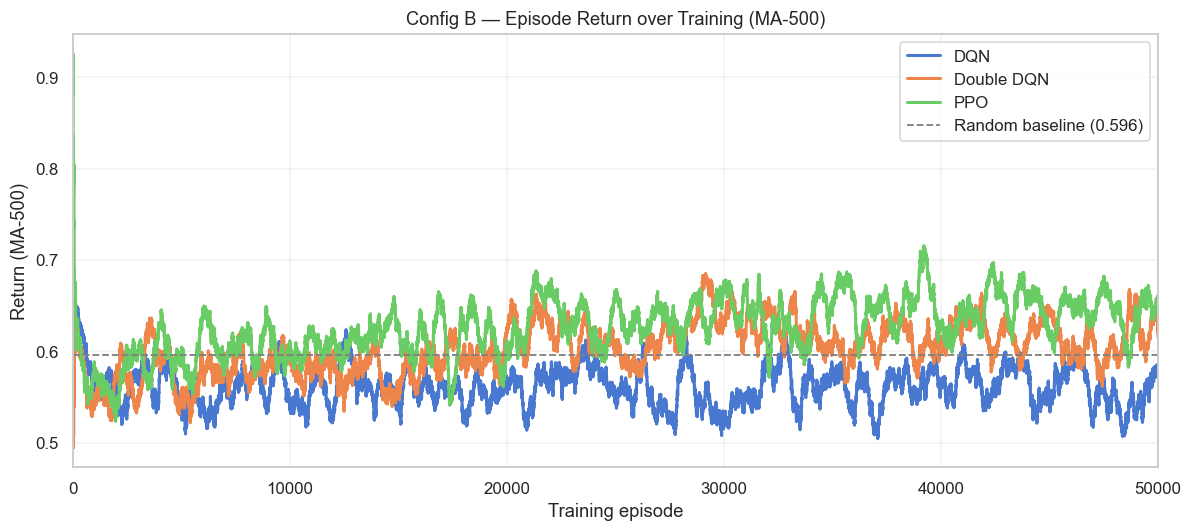

In [ ]:
histories = {
    'Double DQN': hist_ddqn,
    'PPO':        hist_ppo,
}
baselines = {
    f'Random baseline ({clinical_rand_mean:.3f})': clinical_rand_mean,
}

plot_return_curves(
    histories,
    window=MA_WINDOW,
    title=f'Config B — Episode Return over Training (MA-{MA_WINDOW})',
    baselines=baselines,
    max_episodes=N_EPISODES,
    savepath=f'{PLOTS_DIR}/configB_returns.png',
)

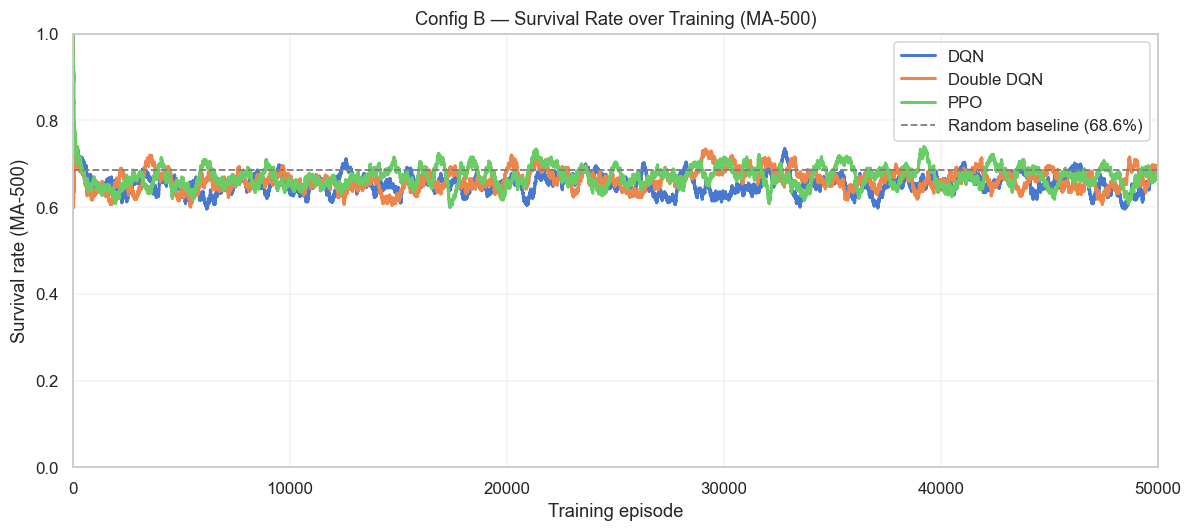

In [ ]:
baselines_surv = {
    f'Random baseline ({clinical_rand_surv:.1%})': clinical_rand_surv,
}

plot_survival_curves(
    histories,
    window=MA_WINDOW,
    title=f'Config B — Survival Rate over Training (MA-{MA_WINDOW})',
    baselines=baselines_surv,
    max_episodes=N_EPISODES,
    savepath=f'{PLOTS_DIR}/configB_survival.png',
)

A plot comparing the training loss curves of the two algorithms with the best hyperparameters (Double DQN and PPO).

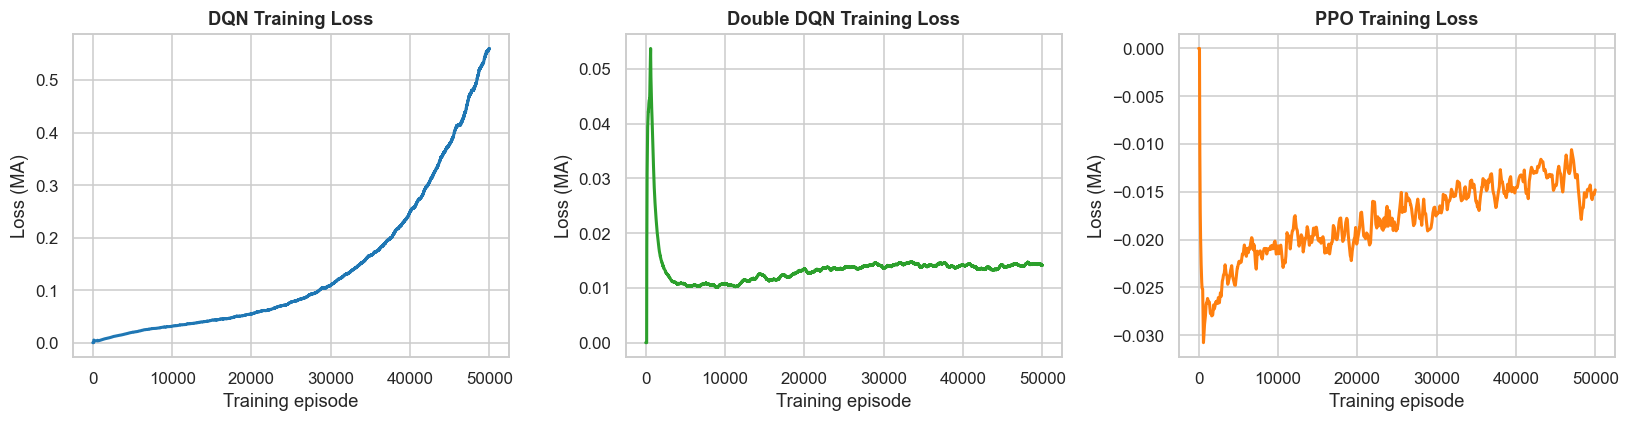

In [ ]:
# Training loss curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, label, hist, color in [
    (axes[0], 'Double DQN', hist_ddqn, GREEN),
    (axes[1], 'PPO',        hist_ppo,  ORANGE),
]:
    ma_loss = moving_average(hist['losses'], MA_WINDOW)
    ax.plot(np.arange(len(ma_loss)), ma_loss, color=color, linewidth=2)
    ax.set_xlabel('Training episode')
    ax.set_ylabel('Loss (MA)')
    ax.set_title(f'{label} Training Loss', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_losses.png', bbox_inches='tight')
plt.show()

### 5a. DQN-specific plots

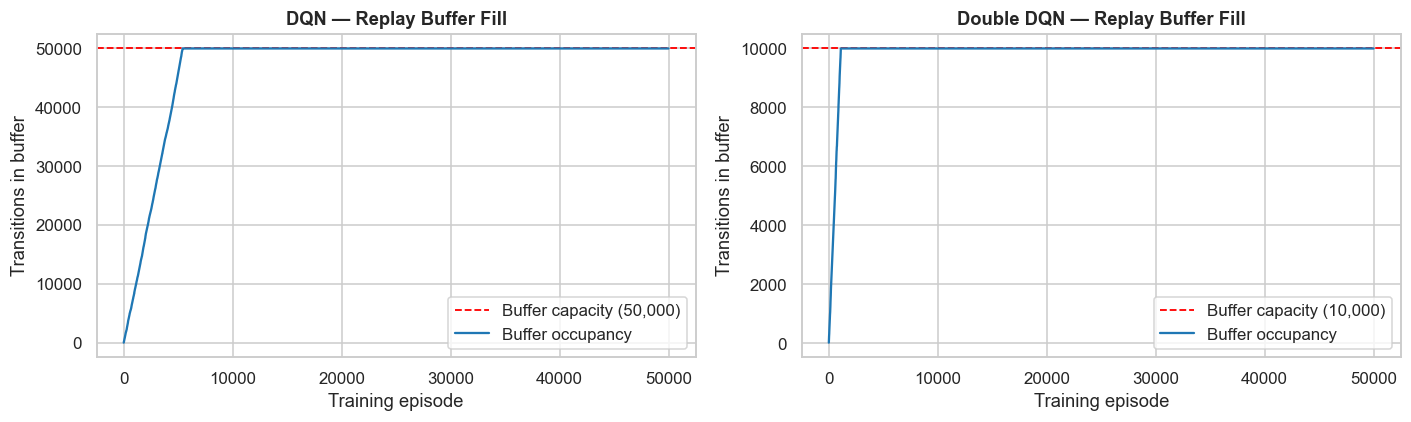

In [ ]:
# Buffer occupancy over training - shows when the replay buffer reaches its maximum capacity

fig, ax = plt.subplots(figsize=(8, 4))

buffer_size = best_params_ddqn['buffer_size']
buffer_occupancy = np.minimum(np.cumsum(hist_ddqn['lengths']), buffer_size)

ax.plot(
    buffer_occupancy,
    color=BLUE,
    linewidth=1.8,
    label='Buffer occupancy'
)

ax.axhline(
    buffer_size,
    color='red',
    linestyle='--',
    linewidth=1.2,
    label=f'Buffer capacity ({buffer_size:,})'
)

ax.set_xlabel('Training episode')
ax.set_ylabel('Transitions in buffer')
ax.set_title('Double DQN — Replay Buffer Fill', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_ddqn_buffer_fill.png', bbox_inches='tight')
plt.show()

---
## 6. Evaluation

All trained agents are evaluated on the same 1 000 greedy episodes
(no exploration). We stratify results by wrapper flag to understand each
agent's robustness to the clinical failure modes.

In [ ]:
agents = {'Double DQN': agent_ddqn, 'PPO': agent_ppo}
eval_results = {}

for name, agent in agents.items():
    m = evaluate_policy_b(agent, n_episodes=EVAL_EPISODES, seed=SEED)
    s = m.summary()
    eval_results[name] = {'metrics': m, 'summary': s}
    print(f"{name:13s} | return={s['mean_return']:.4f} | "
          f"survival={s['survival_rate']:.2%} | length={s['mean_length']:.2f}")

print()
print(f"Random baseline  | return={clinical_rand_mean:.4f} | "
      f"survival={clinical_rand_surv:.2%}")

make_sepsis_env | lam=0.02 -> intensity penalty active
make_sepsis_env | sofa_bias=5.0 -> mean start SOFA: 9.02
DQN           | return=0.5859 | survival=68.10% | length=9.57
make_sepsis_env | lam=0.02 -> intensity penalty active
make_sepsis_env | sofa_bias=5.0 -> mean start SOFA: 9.02
Double DQN    | return=0.6233 | survival=67.20% | length=8.42
make_sepsis_env | lam=0.02 -> intensity penalty active
make_sepsis_env | sofa_bias=5.0 -> mean start SOFA: 9.02
PPO           | return=0.6763 | survival=69.10% | length=7.91

Random baseline  | return=0.5962 | survival=68.60%


In [ ]:
# Stratified evaluation: noisy, missing, acute
for name, agent in agents.items():
    m = evaluate_policy_b(agent, n_episodes=2000, seed=SEED)
    returns_arr  = np.array(m.episode_returns)
    noisy_mask   = np.array(m.noisy_flags)
    missing_mask = np.array(m.missing_flags)
    acute_mask   = np.array(m.acute_flags)

    print(f'\n=== {name} — stratified evaluation (2000 episodes) ===')
    for mask, lbl in [(noisy_mask,  'Noisy'),
                      (~noisy_mask, 'Clean'),
                      (missing_mask,'Missing obs'),
                      (~missing_mask,'Complete obs'),
                      (acute_mask,  'Acute event'),
                      (~acute_mask, 'No acute')]:
        if mask.sum() == 0:
            continue
        sel = returns_arr[mask]
        print(f'  {lbl:16s} n={mask.sum():4d}  return={np.mean(sel):.4f}  surv={np.mean(sel>0):.1%}')

make_sepsis_env | lam=0.02 -> intensity penalty active
make_sepsis_env | sofa_bias=5.0 -> mean start SOFA: 9.02

=== DQN — stratified evaluation (2000 episodes) ===
  Noisy            n= 315  return=0.5647  surv=66.3%
  Clean            n=1685  return=0.5716  surv=66.6%
  Missing obs      n= 320  return=0.5751  surv=66.9%
  Complete obs     n=1680  return=0.5696  surv=66.5%
  Acute event      n= 171  return=-0.0830  surv=0.0%
  No acute         n=1829  return=0.6316  surv=72.8%
make_sepsis_env | lam=0.02 -> intensity penalty active
make_sepsis_env | sofa_bias=5.0 -> mean start SOFA: 9.02

=== Double DQN — stratified evaluation (2000 episodes) ===
  Noisy            n= 296  return=0.6313  surv=67.9%
  Clean            n=1704  return=0.6299  surv=67.7%
  Missing obs      n= 303  return=0.5949  surv=64.4%
  Complete obs     n=1697  return=0.6364  surv=68.4%
  Acute event      n= 149  return=-0.0411  surv=0.0%
  No acute         n=1851  return=0.6841  surv=73.2%
make_sepsis_env | lam=0.02 

---
## 7. Failure Mode Sensitivity Analysis

We vary each wrapper intensity while holding the others fixed, to understand
how robust the best agent is to increasing clinical realism.

Best agent for sensitivity analysis: PPO
make_sepsis_env | lam=0.02 -> intensity penalty active
make_sepsis_env | sofa_bias=5.0 -> mean start SOFA: 9.02
make_sepsis_env | lam=0.02 -> intensity penalty active
make_sepsis_env | sofa_bias=5.0 -> mean start SOFA: 9.02
make_sepsis_env | lam=0.02 -> intensity penalty active
make_sepsis_env | sofa_bias=5.0 -> mean start SOFA: 9.02
make_sepsis_env | lam=0.02 -> intensity penalty active
make_sepsis_env | sofa_bias=5.0 -> mean start SOFA: 9.02
make_sepsis_env | lam=0.02 -> intensity penalty active
make_sepsis_env | sofa_bias=5.0 -> mean start SOFA: 9.02
make_sepsis_env | lam=0.02 -> intensity penalty active
make_sepsis_env | sofa_bias=5.0 -> mean start SOFA: 9.02
make_sepsis_env | lam=0.02 -> intensity penalty active
make_sepsis_env | sofa_bias=5.0 -> mean start SOFA: 9.02
make_sepsis_env | lam=0.02 -> intensity penalty active
make_sepsis_env | sofa_bias=5.0 -> mean start SOFA: 9.02
make_sepsis_env | lam=0.02 -> intensity penalty active
make_sep

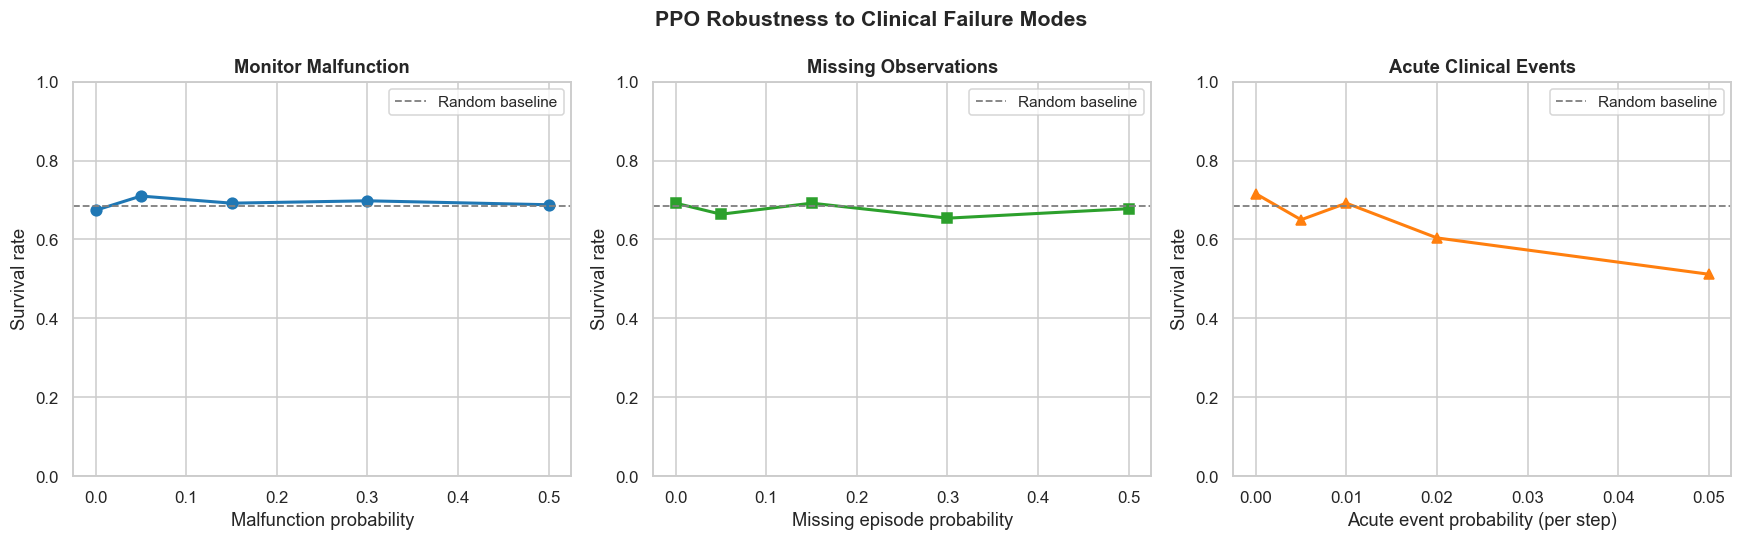

In [ ]:
# Use the best-performing agent on clean evaluation
best_agent_name = max(eval_results, key=lambda n: eval_results[n]['summary']['survival_rate'])
best_agent      = agents[best_agent_name]
print(f'Best agent for sensitivity analysis: {best_agent_name}')

noise_probs   = [0.0, 0.05, 0.15, 0.30, 0.50]
missing_probs = [0.0, 0.05, 0.15, 0.30, 0.50]
event_probs   = [0.0, 0.005, 0.01, 0.02, 0.05]

noise_results   = []
missing_results = []
event_results   = []

for prob in noise_probs:
    m = evaluate_policy_b(best_agent, n_episodes=500, seed=SEED, malfunction_prob=prob).summary()
    noise_results.append({'malfunction_prob': prob, **m})

for prob in missing_probs:
    m = evaluate_policy_b(best_agent, n_episodes=500, seed=SEED, missing_prob=prob).summary()
    missing_results.append({'missing_prob': prob, **m})

for prob in event_probs:
    m = evaluate_policy_b(best_agent, n_episodes=500, seed=SEED, event_prob=prob).summary()
    event_results.append({'event_prob': prob, **m})

noise_df   = pd.DataFrame(noise_results)
missing_df = pd.DataFrame(missing_results)
event_df   = pd.DataFrame(event_results)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(noise_df['malfunction_prob'],  noise_df['survival_rate'],
             'o-', color=BLUE, linewidth=2, markersize=7)
axes[0].set_title('Monitor Malfunction', fontweight='bold')
axes[0].set_xlabel('Malfunction probability')
axes[0].set_ylabel('Survival rate')
axes[0].set_ylim(0, 1)

axes[1].plot(missing_df['missing_prob'], missing_df['survival_rate'],
             's-', color=GREEN, linewidth=2, markersize=7)
axes[1].set_title('Missing Observations', fontweight='bold')
axes[1].set_xlabel('Missing episode probability')
axes[1].set_ylabel('Survival rate')
axes[1].set_ylim(0, 1)

axes[2].plot(event_df['event_prob'], event_df['survival_rate'],
             '^-', color=ORANGE, linewidth=2, markersize=7)
axes[2].set_title('Acute Clinical Events', fontweight='bold')
axes[2].set_xlabel('Acute event probability (per step)')
axes[2].set_ylabel('Survival rate')
axes[2].set_ylim(0, 1)

for ax in axes:
    ax.axhline(clinical_rand_surv, color='gray', linestyle='--',
               linewidth=1.2, label='Random baseline')
    ax.legend(fontsize=10)

fig.suptitle(f'{best_agent_name} Robustness to Clinical Failure Modes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_failure_mode_sensitivity.png', bbox_inches='tight')
plt.show()

---
## 8. Final Comparison

In [ ]:
# Summary table
rows = []
rows.append({
    'Algorithm': 'Random',
    'Mean Return': clinical_rand_mean,
    'Survival Rate': clinical_rand_surv,
    'Training Episodes': 0,
    'buffer_size': '-',
    'target_update_freq': '-',
})
for name in ['Double DQN', 'PPO']:
    s = eval_results[name]['summary']
    row = {
        'Algorithm': name,
        'Mean Return': round(s['mean_return'], 4),
        'Survival Rate': round(s['survival_rate'], 4),
        'Training Episodes': N_EPISODES,
    }
    if name in ('Double DQN'):
        p = best_params_ddqn
        row['buffer_size']        = p['buffer_size']
        row['target_update_freq'] = p['target_update_freq']
    else:
        row['buffer_size']        = 'N/A (on-policy)'
        row['target_update_freq'] = 'N/A (on-policy)'
    rows.append(row)

comparison_df = pd.DataFrame(rows)
print('Final comparison table:')
display(comparison_df)

Final comparison table:


,Algorithm,Mean Return,Survival Rate,Training Episodes,buffer_size,target_update_freq
0,Random,0.596157,0.686,0,-,-
1,DQN,0.585900,0.681,50000,50000,50
2,Double DQN,0.623300,0.672,50000,10000,100
3,PPO,0.676300,0.691,50000,N/A (on-policy),N/A (on-policy)


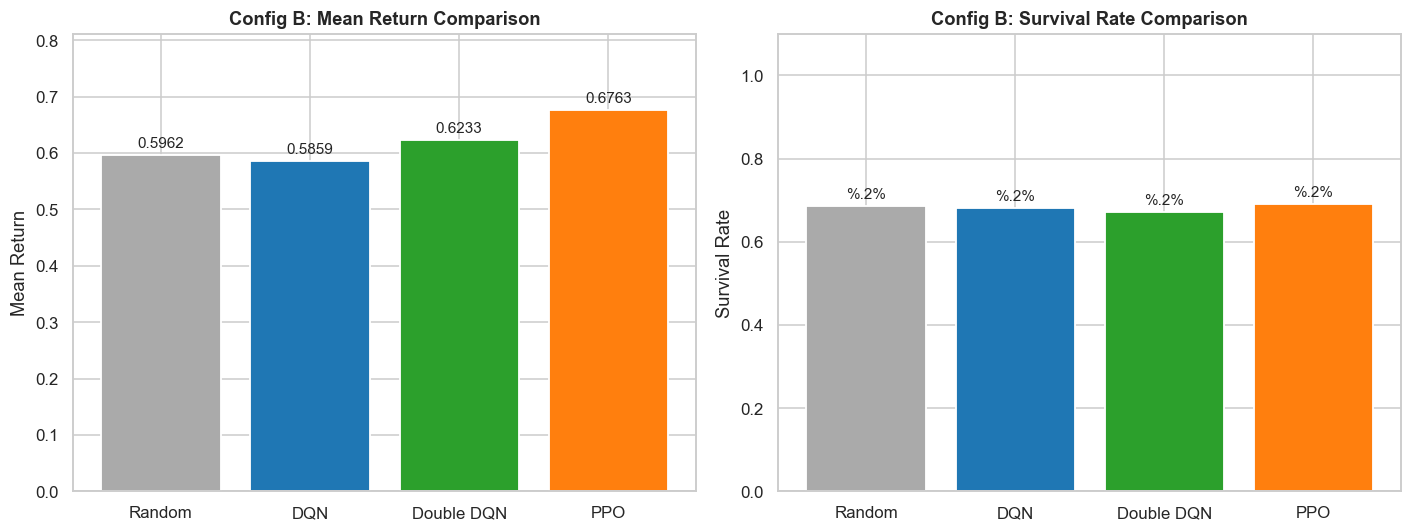

Improvement over random baseline:
  DQN           return Δ=-0.0103  survival Δ=-0.0050
  Double DQN    return Δ=+0.0271  survival Δ=-0.0140
  PPO           return Δ=+0.0802  survival Δ=+0.0050


In [ ]:
# Bar chart — mean return
algos  = comparison_df['Algorithm'].tolist()
rets   = comparison_df['Mean Return'].tolist()
colors = ['#aaaaaa', BLUE, GREEN, ORANGE]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(algos, rets, color=colors, edgecolor='white', linewidth=1.2)
axes[0].bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
axes[0].set_ylabel('Mean Return')
axes[0].set_title('Config B: Mean Return Comparison', fontweight='bold')
axes[0].set_ylim(0, max(rets) * 1.2)

survs = comparison_df['Survival Rate'].tolist()
bars2 = axes[1].bar(algos, survs, color=colors, edgecolor='white', linewidth=1.2)
axes[1].bar_label(bars2, fmt='%.2%', padding=3, fontsize=10)
axes[1].set_ylabel('Survival Rate')
axes[1].set_title('Config B: Survival Rate Comparison', fontweight='bold')
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_final_comparison.png', bbox_inches='tight')
plt.show()

# Print improvement over random
rand_ret  = clinical_rand_mean
rand_surv = clinical_rand_surv
print('Improvement over random baseline:')
for name in ['Double DQN', 'PPO']:
    s = eval_results[name]['summary']
    print(f"  {name:13s} return Δ={s['mean_return']-rand_ret:+.4f}  "
          f"survival Δ={s['survival_rate']-rand_surv:+.4f}")

### Summary

- The **random baseline** establishes the performance floor on the full clinical
  environment with all three wrappers active.
- **DQN** and **Double DQN** are off-policy value-based methods; their key
  hyperparameters are the **replay buffer size** and the **target network update
  frequency**. A buffer that is too small leads to catastrophic forgetting;
  a target update frequency that is too high reintroduces moving-target
  instability. The Optuna search quantifies these trade-offs.
- **PPO** is an on-policy policy-gradient method with no replay buffer and no
  target network — its stability comes from the clipped objective and fresh
  rollout data, not from the DQN stabilisation mechanisms.
- The failure-mode analysis shows how each agent degrades as wrapper intensity
  increases, revealing which clinical failure mode poses the greatest challenge.